# Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from dfply import *

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


# Load settings

In [2]:
from re import search

if search("BI2404M", os.uname()[1]):
    exec(open('/Users/argelagr/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())
elif search("ebi", os.uname()[1]):
    exec(open('/homes/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/utils.py').read())
else:
    exit("Computer not recognised")

## Define I/O

In [36]:
io["outdir"] = Path(io["basedir"]) / "results/rna/metacells/trajectories/nmp"

## Define options 

In [4]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(8, 7), facecolor='white')

In [5]:
opts["samples"] = [
#	"E7.5_rep1",
#	"E7.5_rep2",
#  	"E7.75_rep1",
#	"E8.0_rep1",
#	"E8.0_rep2",
#	"E8.5_rep1",
#	"E8.5_rep2",
#	"E8.75_rep1",
#	"E8.75_rep2",
	"E8.5_CRISPR_T_KO",
	"E8.5_CRISPR_T_WT"
]

opts["celltypes"] = [
  "Caudal_Mesoderm",
  "Somitic_mesoderm",
  "NMP",
  "Spinal_cord"
]

## Load cell metadata

In [6]:
metadata = (pd.read_table(io["metadata"]) >>
    mask(X["pass_rnaQC"]==True, X["doublet_call"]==False) >>
    mask(X["sample"].isin(opts["samples"]), X["celltype.mapped"].isin(opts["celltypes"]))
)
metadata.shape

(2402, 23)

In [7]:
metadata.head()

,cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,genotype,pass_rnaQC,...,celltype.score,closest.cell,TSSEnrichment_atac,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC,celltype.predicted
42585,E8.5_CRISPR_T_KO#AAAGCCCGTGATTTGG-1,AAAGCCCGTGATTTGG-1,E8.5_CRISPR_T_KO,4452.0,29506.0,12.19,14.63,E8.5,T_KO,True,...,0.88,cell_67837,17.56,7199.0,0.25,1.10,53885.0,0.02,True,NMP
42587,E8.5_CRISPR_T_KO#AAAGCCCGTTATCCGT-1,AAAGCCCGTTATCCGT-1,E8.5_CRISPR_T_KO,4016.0,21776.0,9.22,10.59,E8.5,T_KO,True,...,1.00,cell_76787,17.96,1043.0,0.21,0.86,9358.0,0.02,True,Spinal_cord
42591,E8.5_CRISPR_T_KO#AAAGCCGCAATAATGG-1,AAAGCCGCAATAATGG-1,E8.5_CRISPR_T_KO,4148.0,26774.0,8.72,18.00,E8.5,T_KO,True,...,1.00,cell_138598,19.11,4681.0,0.29,1.27,30553.0,0.11,False,NMP
42596,E8.5_CRISPR_T_KO#AAAGCTTGTTGCTTCG-1,AAAGCTTGTTGCTTCG-1,E8.5_CRISPR_T_KO,5103.0,30922.0,4.18,10.12,E8.5,T_KO,True,...,1.00,cell_135203,19.19,3479.0,0.25,1.04,24903.0,0.02,True,NMP
42614,E8.5_CRISPR_T_KO#AAAGGTTAGCGATAGA-1,AAAGGTTAGCGATAGA-1,E8.5_CRISPR_T_KO,5450.0,35164.0,4.54,10.53,E8.5,T_KO,True,...,1.00,cell_75526,23.41,4007.0,0.29,0.86,24411.0,0.02,True,NMP


# Load anndata object

In [77]:
adata = load_adata(
    adata_file = io["anndata"], 
    cells = metadata.cell.values, 
    normalise = True, 
    filter_lowly_expressed_genes = True,
    set_colors = False
)
adata

Trying to set attribute `.var` of view, copying.


AnnData object with n_obs × n_vars = 2402 × 19597
    obs: 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype.mapped', 'celltype.score', 'closest.cell', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC', 'celltype.predicted'
    var: 'gene', 'n_counts'
    uns: 'celltype.mapped_colors', 'stage_colors', 'log1p'

In [9]:
adata.obs = adata.obs.rename(columns={"celltype.mapped":"celltype"})

In [10]:
colPalette_celltypes = [opts["celltype_colors"][i.replace(" ","_")] for i in sorted(np.unique(adata.obs['celltype']))]
adata.uns['celltype_colors'] = colPalette_celltypes
#colPalette_stages = [opts["stages_colors"][i.replace(" ","_")] for i in sorted(np.unique(adata.obs['stage']))]
#adata.uns['stage_colors'] = colPalette_stages

## Feature selection

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=1500)

In [12]:
adata.var["highly_variable"].sum()

1500

# Dimensionality reduction

## PCA

Run PCA

In [13]:
sc.tl.pca(adata, n_comps=50)

Plot PCA

In [14]:
# sc.pl.pca(adata, components=[1,2], color=["celltype"], size=25, legend_loc=None)

In [15]:
# sc.external.pp.harmony_integrate(adata, key = "sample", basis='X_pca', adjusted_basis='X_pca_harmony')

## k-NN graph

Build kNN graph

In [16]:
sc.pp.neighbors(adata, n_neighbors=25, use_rep='X_pca')

## UMAP

Run UMAP

In [17]:
sc.tl.umap(adata, min_dist=0.5, n_components=2)

Plot UMAP

findfont: Font family ['Bitstream Vera Sans'] not found. Falling back to DejaVu Sans.


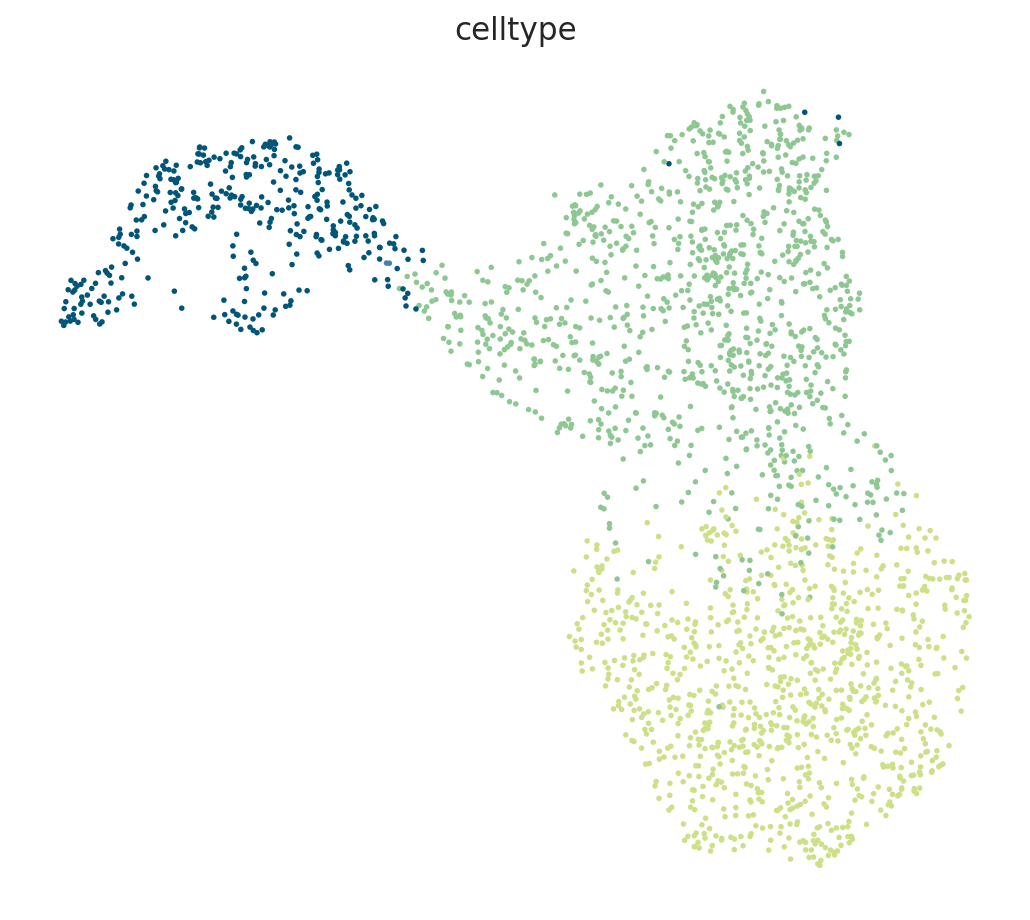

In [18]:
sc.pl.umap(adata, color=["celltype"], size=25, legend_loc=None)

## Force-directed layout

In [19]:
sc.tl.draw_graph(adata, layout="fa", init_pos=None)

findfont: Font family ['Bitstream Vera Sans'] not found. Falling back to DejaVu Sans.


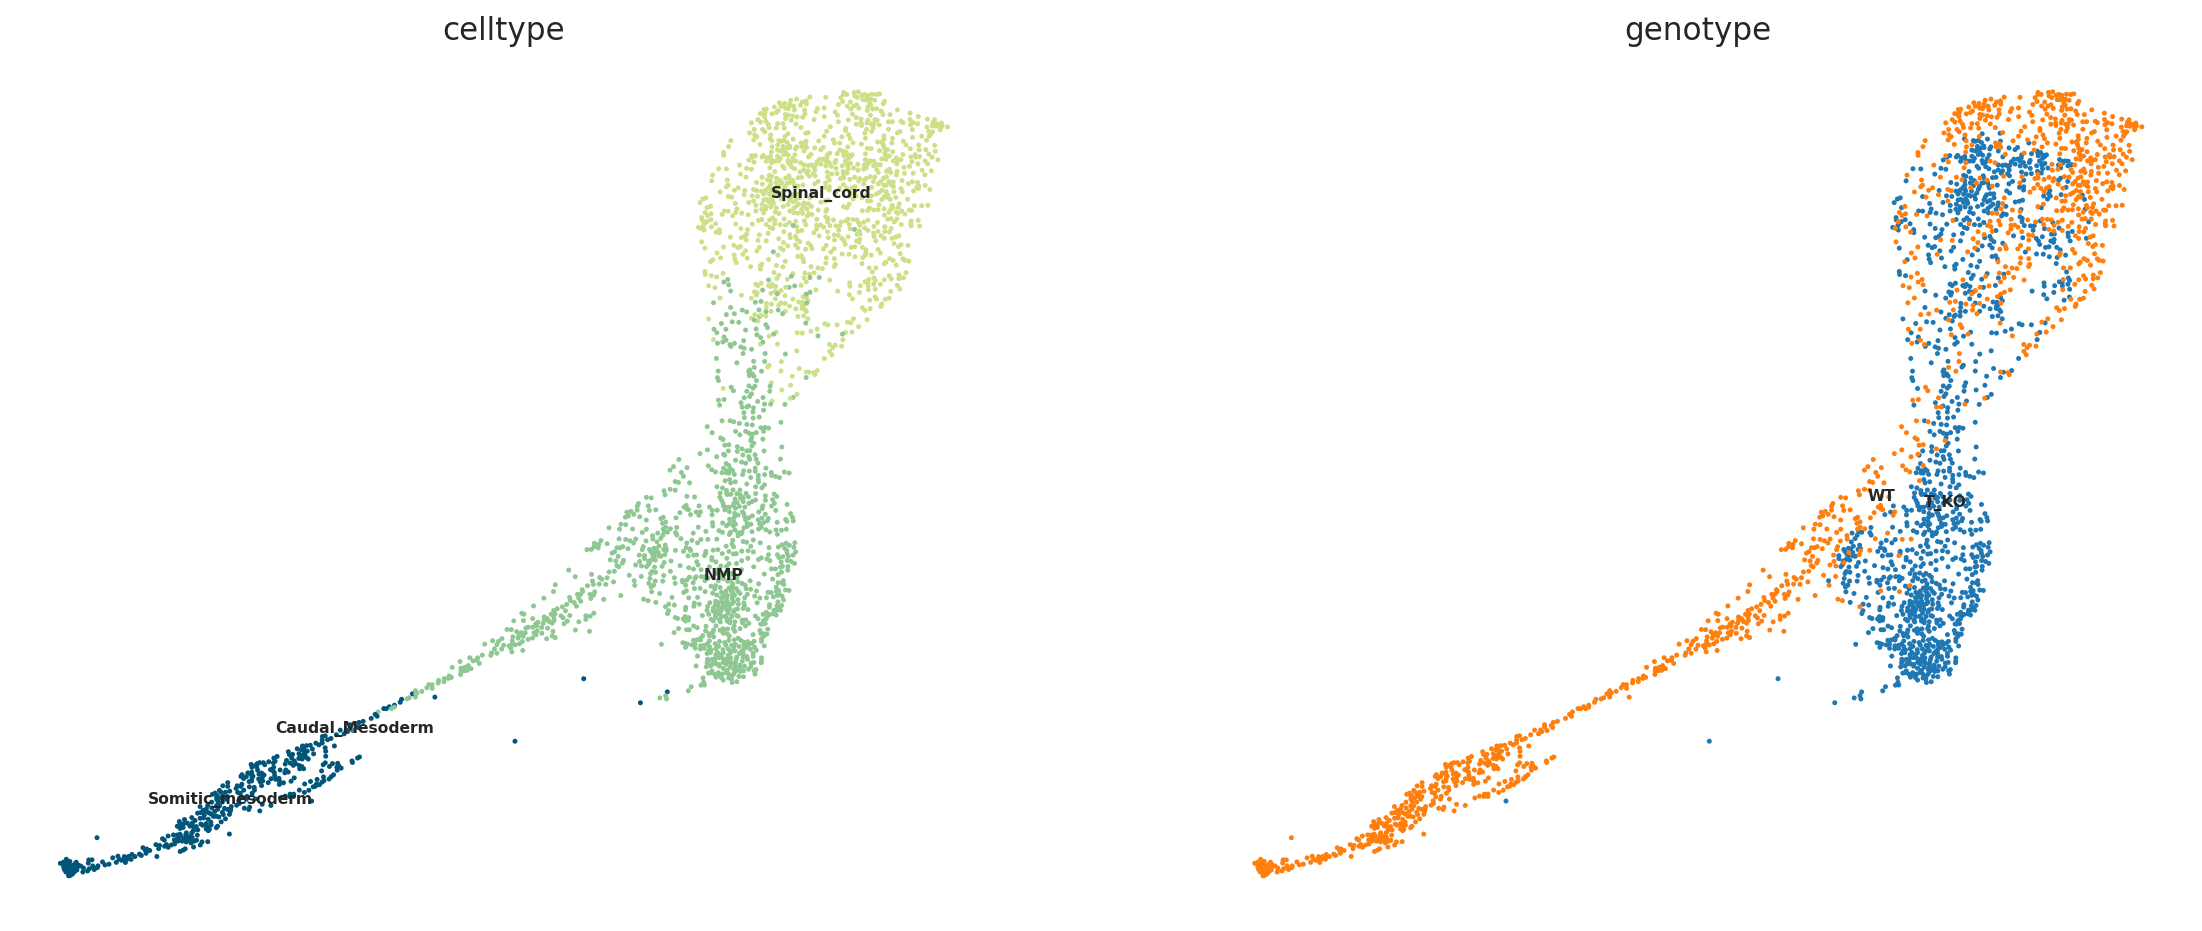

In [21]:
sc.pl.draw_graph(adata, color=["celltype","genotype"], size=20, legend_loc='on data', legend_fontsize=7)

In [22]:
adata.obsm

AxisArrays with keys: X_pca, X_umap, X_draw_graph_fa

## Metacells

Parameters

In [28]:
n_metacells = 100
build_kernel_on = 'X_draw_graph_fa'
n_waypoint_eigs = 10
waypoint_proportion = 1

In [29]:
model = SEACells.core.SEACells(adata, 
                  build_kernel_on=build_kernel_on, 
                  n_SEACells=n_metacells, 
                  n_waypoint_eigs=n_waypoint_eigs,
                  waypt_proportion=waypoint_proportion,
                  convergence_epsilon = 1e-5,
                  verbose = True)

# model.fit(n_iter=2)
model.fit()

Building kernel...
Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/2402 [00:00<?, ?it/s]

Making graph symmetric...
Computing RBF kernel...


  0%|          | 0/2402 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/2402 [00:00<?, ?it/s]

Constructing CSR matrix...
Building kernel on X_draw_graph_fa
Computing diffusion components from X_draw_graph_fa for waypoint initialization ... 
Determing nearest neighbor graph...
Done.
Sampling waypoints ...
Done.
Selecting 90 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


  0%|          | 0/20 [00:00<?, ?it/s]

Selecting 10 cells from greedy initialization.
Randomly initialized A matrix.
Setting convergence threshold at 2.2691330215145245
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Converged after 10 iterations.


Model Convergence

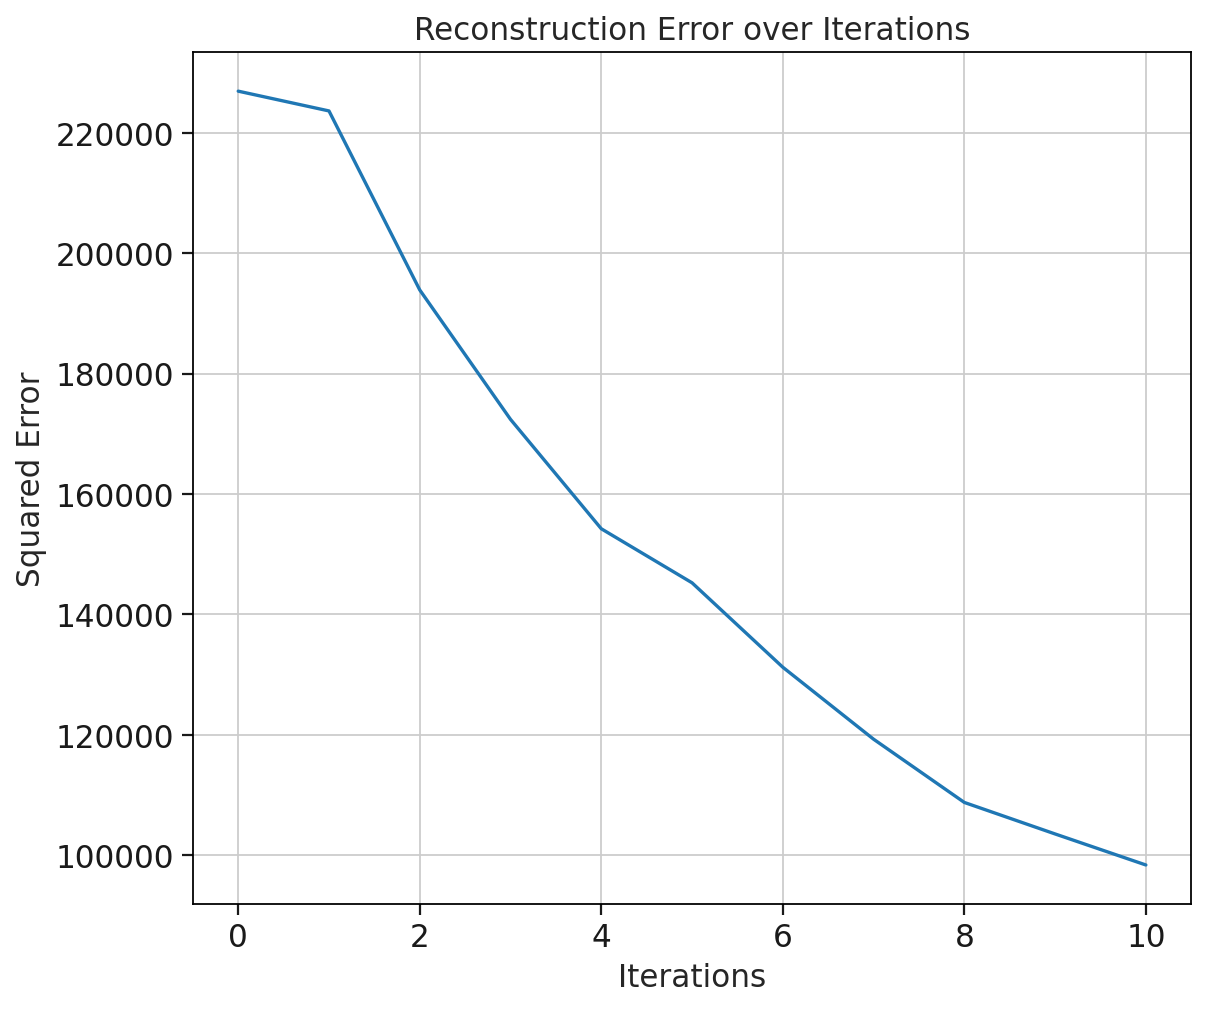

In [30]:
model.plot_convergence()

SEACell Assignments


In [31]:
adata.obs[['SEACell']].head()

,SEACell
index,
E8.5_CRISPR_T_KO#AAAGCCCGTGATTTGG-1,E8.5_CRISPR_T_KO#CGGGTATGTTGCGGAT-1
E8.5_CRISPR_T_KO#AAAGCCCGTTATCCGT-1,E8.5_CRISPR_T_KO#CGCAATGTCCGCAAGC-1
E8.5_CRISPR_T_KO#AAAGCCGCAATAATGG-1,E8.5_CRISPR_T_WT#ACACTTGCAGCTTACA-1
E8.5_CRISPR_T_KO#AAAGCTTGTTGCTTCG-1,E8.5_CRISPR_T_KO#GAGAAACGTAACCAGC-1
E8.5_CRISPR_T_KO#AAAGGTTAGCGATAGA-1,E8.5_CRISPR_T_KO#CTTCAGGAGCGATACT-1


Summarizing data


In [32]:
# adata_metacells = SEACells.core.summarize_by_SEACell(adata, SEACells_label='SEACell', summarize_layer='raw')
# adata_metacells

Visualise Results            

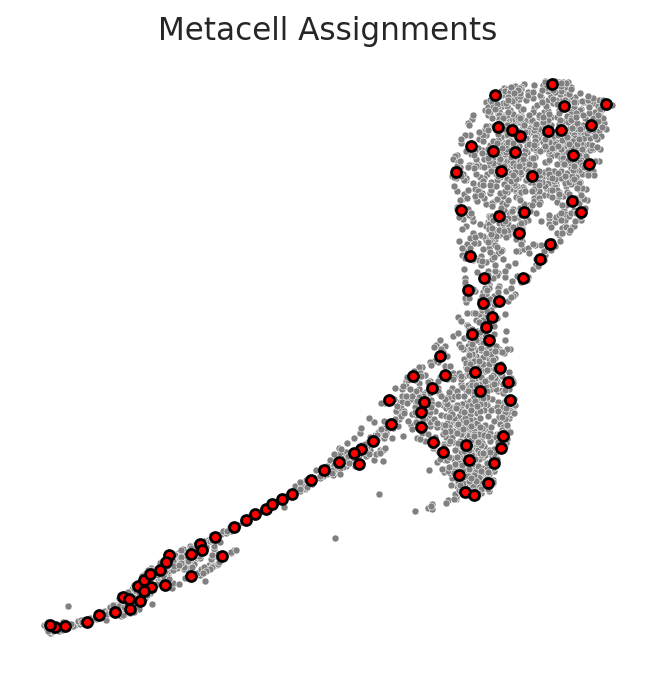

In [33]:
SEACells.plot.plot_2D(adata, key='X_draw_graph_fa', colour_metacells=False)

Save assignments

In [38]:
outfile = io["outdir"] / "cell2metacell_assignment.txt.gz"

In [40]:
to_save = adata.obs[['SEACell']].reset_index()
to_save.columns = ["cell","metacell"]
to_save.to_csv(outfile, sep="\t", header=True, index=False)

## Test

In [45]:
adata_metacells = SEACells.core.summarize_by_SEACell(adata, SEACells_label='SEACell', summarize_layer='raw')

  0%|          | 0/100 [00:00<?, ?it/s]

In [66]:
adata_metacells.uns = adata.uns

In [61]:
adata_metacells.obs = (adata.obs.loc[adata_metacells.obs.index] >> 
    select(["sample","celltype","genotype"])
)

In [62]:
sc.pp.normalize_total(adata_metacells)
sc.pp.log1p(adata_metacells)

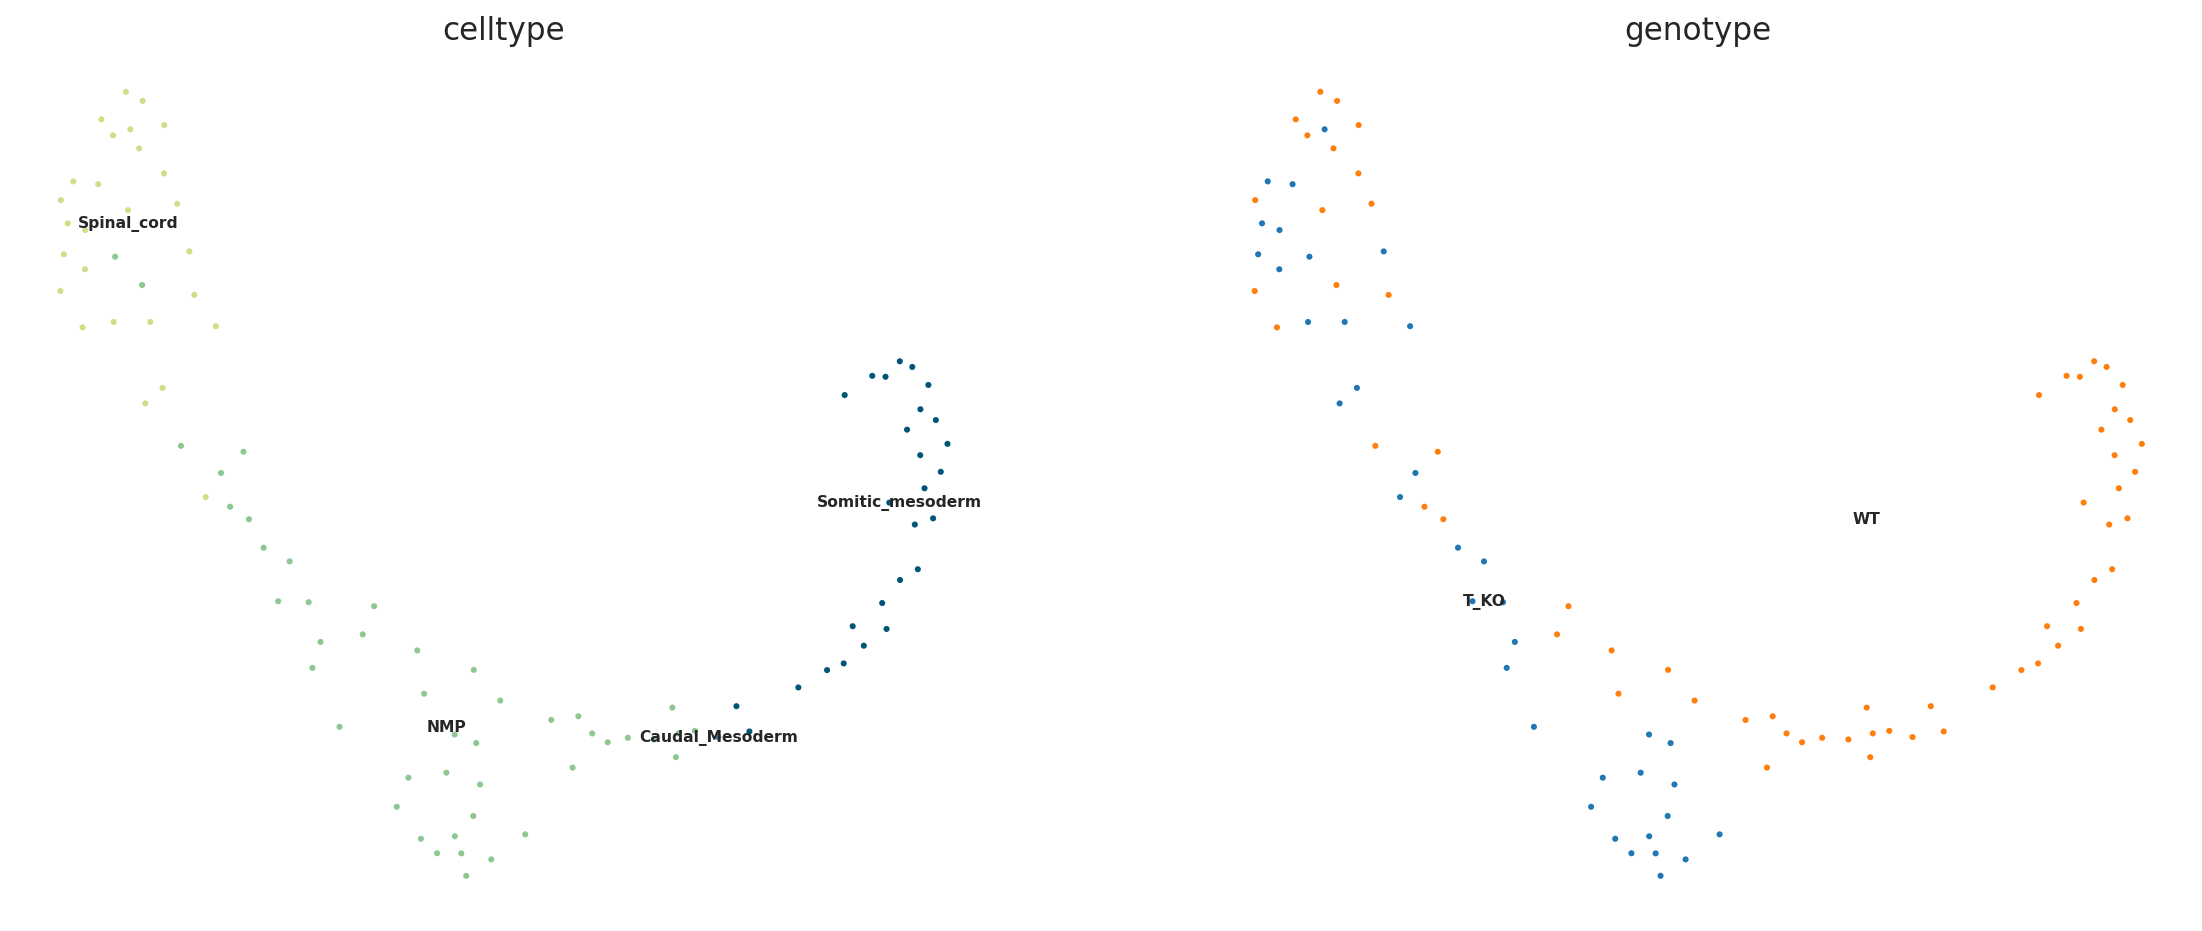

In [68]:
sc.pp.highly_variable_genes(adata_metacells, n_top_genes=1500)
sc.tl.pca(adata_metacells, n_comps=10)
sc.pp.neighbors(adata_metacells, n_neighbors=15, use_rep='X_pca')
sc.tl.draw_graph(adata_metacells, layout="fa", init_pos=None)

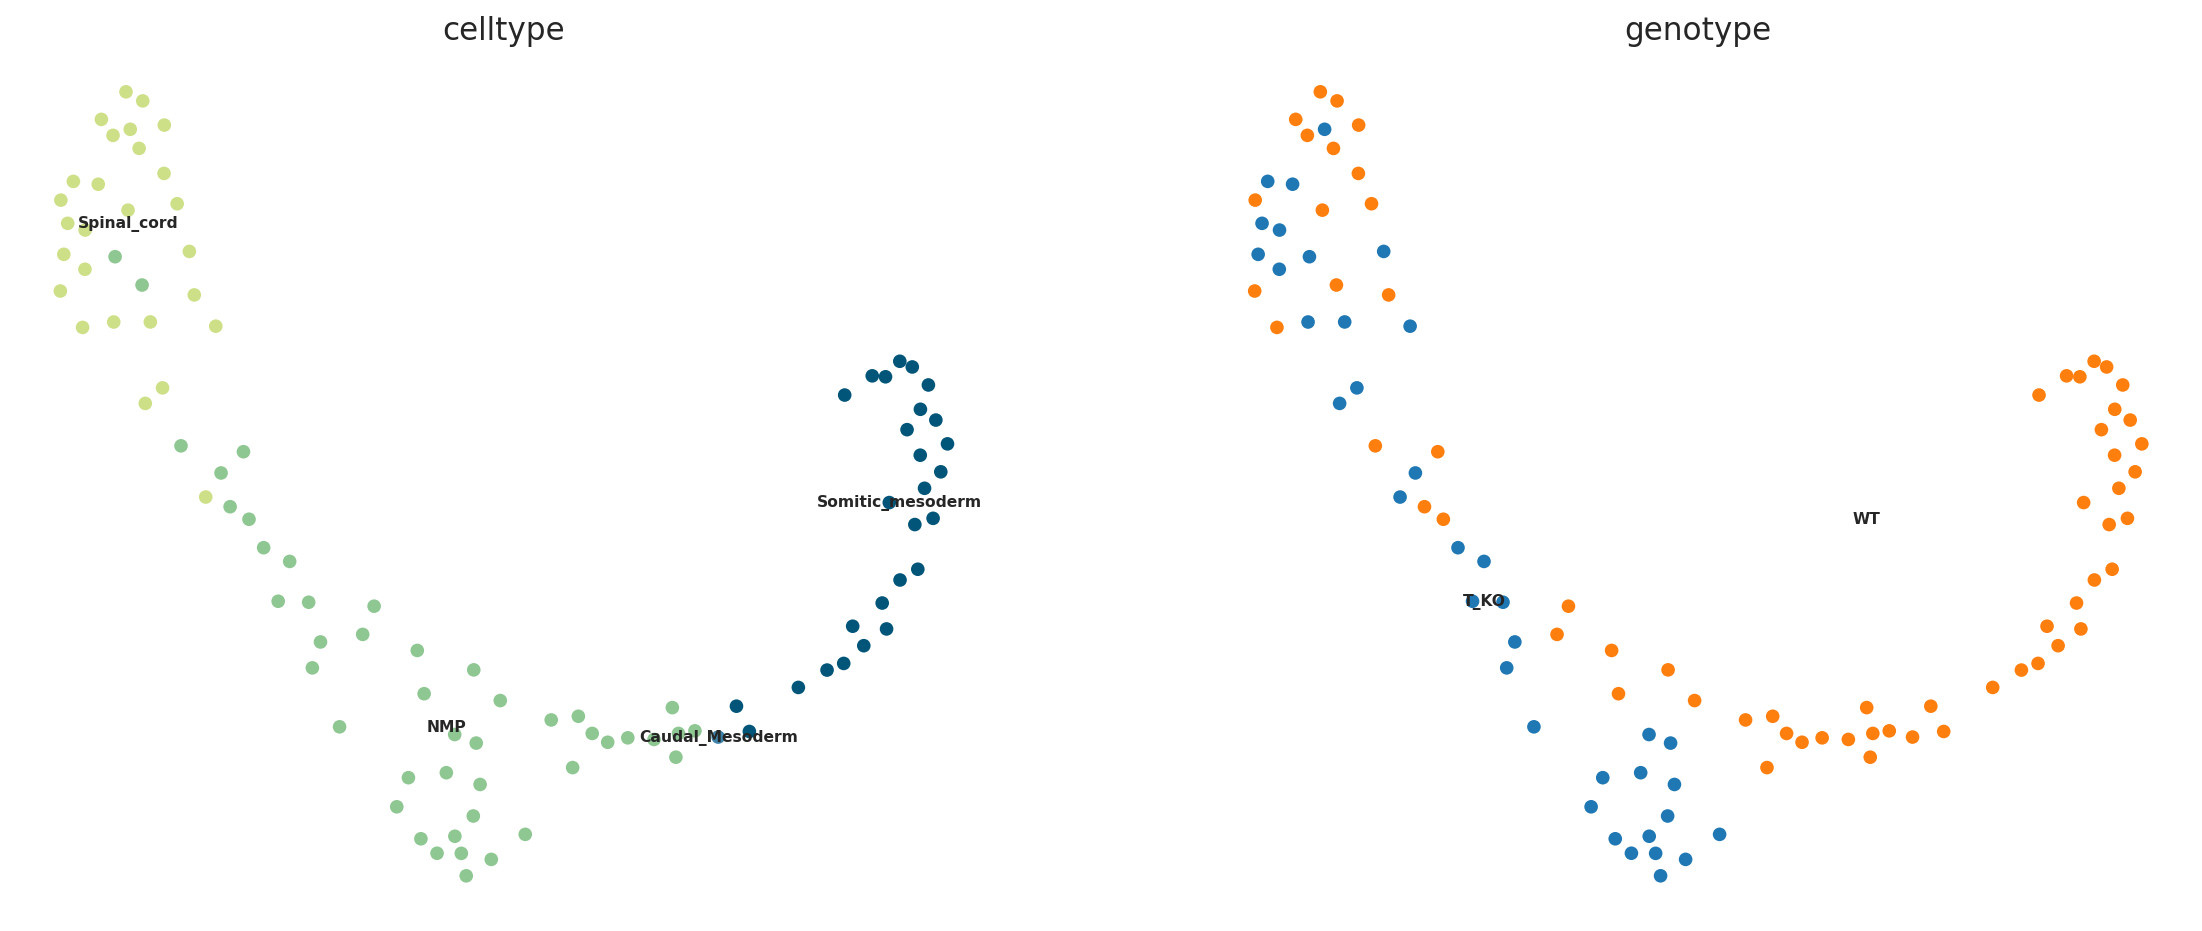

In [72]:
sc.pl.draw_graph(adata_metacells, color=["celltype","genotype"], size=150, legend_loc='on data', legend_fontsize=7)